# Tutorial: Run CBSS algorithm

This notebook showcases:
- Loading a BIDS recording using the [MUniverse](https://github.com/dfarinagroup/muniverse) package
- Apply the CBSS decomposition algorithm (see [Negro et al. 2016](https://doi.org/10.1088/1741-2560/13/2/026027))
- Format the outputs according to [MUnitQuest](https://munitquest.github.io/registration_and_submission/) requirements

### Requirements

To run the code make sure you have installed MUniverse (see the installation guide).

In [61]:
# Import required packages
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from muniverse.algorithms import decompose_recording
from muniverse.utils.data2bids import bids_emg_recording, bids_decomp_derivatives

from pathlib import Path

Next we will define some handy helper functions

In [69]:
def get_indices(df, c, v):
    """
    Helper function extracting the indices of a dataframe df
    corresponding to values v in column c.
    
    """

    idx = df.index[df[c] == v].tolist()

    return idx

def print_tree(root, max_depth=None, show_hidden=False):
    """
    Print a directory tree.

    Parameters
    ----------
    root : str or Path
        Root directory
    max_depth : int or None
        Max recursion depth (None = unlimited)
    show_hidden : bool
        Whether to include hidden files (starting with '.')
    """
    root = Path(root)

    def _walk(path, prefix="", depth=0):
        if max_depth is not None and depth > max_depth:
            return

        items = sorted(path.iterdir(), key=lambda x: (x.is_file(), x.name.lower()))

        for i, item in enumerate(items):
            if not show_hidden and item.name.startswith("."):
                continue

            connector = "└── " if i == len(items) - 1 else "├── "
            print(prefix + connector + item.name)

            if item.is_dir():
                extension = "    " if i == len(items) - 1 else "│   "
                _walk(item, prefix + extension, depth + 1)

    print(root.name)
    _walk(root)

### Import data

Here, we select one arbitary recording from the MUniverse benchmark data collection (provided on [Dataverse](https://dataverse.harvard.edu/dataverse/muniverse-datasets)). Make sure you have downloaded the data to run the code. 

/Users/thomi/Documents/CBM/github/muniverse-demo/src/muniverse/utils/data2bids.py:571: UserWarning: File *_electrodes.tsv could not be found in the expected folder.Trying to automatically search for inherited files.
  warnings.warn(
/Users/thomi/Documents/CBM/github/muniverse-demo/src/muniverse/utils/data2bids.py:571: UserWarning: File *_electrodes.json could not be found in the expected folder.Trying to automatically search for inherited files.
  warnings.warn(
/Users/thomi/Documents/CBM/github/muniverse-demo/src/muniverse/utils/data2bids.py:571: UserWarning: File *_coordsystem.json could not be found in the expected folder.Trying to automatically search for inherited files.
  warnings.warn(
/Users/thomi/Documents/CBM/github/muniverse-demo/src/muniverse/utils/data2bids.py:571: UserWarning: File *_events.json could not be found in the expected folder.Trying to automatically search for inherited files.
  warnings.warn(


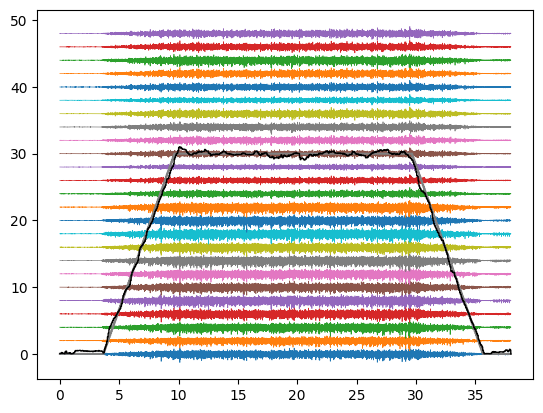

In [63]:
# Load a BIDS recording stored on your hard drive.
emg_recording = bids_emg_recording(
    subject_label="01",
    task_label="isometric30percentmvc",
    datasetname="Caillet_et_al_2023", 
    root=str(Path.home()) + "/Downloads/"
)
emg_recording.read()

# Extract all EMG channels
ch_idx = get_indices(emg_recording.channels, "type", "EMG")
emg_data = emg_recording.emg_data[ch_idx,:]
# Extract the performed torque
ch_idx = get_indices(emg_recording.channels, "description", "performed path")[0]
performed_path = emg_recording.emg_data[ch_idx,:]
# Extract the requested torque 
ch_idx = get_indices(emg_recording.channels, "description", "requested path")[0]
requested_path = emg_recording.emg_data[ch_idx,:]
# Extract start and end of muscle activity from events.tsv
events = emg_recording.events
t_start = events[events["event_type"] == "muscle_on"]["onset"].tolist()[0]
t_end = events[events["event_type"] == "muscle_off"]["onset"].tolist()[0]
idx_start = events[events["event_type"] == "muscle_on"]["sample"].tolist()[0]
idx_end = events[events["event_type"] == "muscle_off"]["sample"].tolist()[0]

# We can plot a few random channels
ploted_channels = range(5,128,5)
n_samples = emg_recording.emg_data.shape[1]
t = np.linspace(0, (n_samples - 1) / emg_recording.fsamp, n_samples)
plt.figure()
for i, ch_idx in enumerate(ploted_channels):
    plt.plot(t,emg_recording.emg_data[ch_idx,:] + 2*i, lw=0.5)
plt.plot(t, requested_path, color="gray") 
plt.plot(t, performed_path, color="black", lw=1)        
plt.show()

### Decompose recording

Next we decompose the recording using the MUniverse implementation of the CBSS algorithm. 

In [ ]:
# Import a configure file
cfg_file = "../../muniverse-demo/configs/cbss.json"
with open(cfg_file, "r") as f:
    cfg = json.load(f)
# Set the time window (extracted from the events file)
cfg['Config']['start_time'] = t_start
cfg['Config']['end_time'] = t_end
cfg['Config']['sampling_frequency'] = emg_recording.fsamp
cfg['Config']['opt_max_iter'] = 1
    
# Run decomposition using CBSS algorithm
results, metadata = decompose_recording(
    data=emg_data,
    method="cbss",
    algorithm_config=cfg
)

KeyboardInterrupt: 

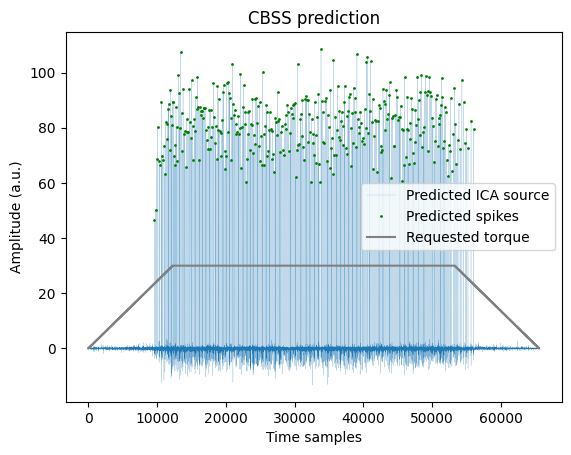

In [ ]:
# Plot some random source
source_0 = results["sources"][0,:] * np.abs(results["sources"][0,:])
spikes_0 = results["spikes"][0]

plt.figure()
plt.plot(source_0, lw=0.1, label="Predicted ICA source")
plt.plot(spikes_0, source_0[spikes_0], 'o', color="green", ms=1, label="Predicted spikes")
plt.plot(requested_path[idx_start:idx_end], color="gray", label="Requested torque")
plt.xlabel("Time samples")
plt.ylabel("Amplitude (a.u.)")
plt.title("CBSS prediction")
plt.legend()
plt.show()

### Save the results to in BIDS format 

Finally we will store the results in the required submission format.
This can be achieved using the MUniverse-BIDS routines.

In [ ]:
cfg_file = "../../muniverse-demo/configs/cbss.json"

# Set-up data class
cbss_prediction = bids_decomp_derivatives(
    parent_recording=emg_recording,
    pipelinename="CBSS",
    format="standalone",
    inherited_metadata=["events.json"],
    inherited_level=["subject"]
)
# Add pipeline metadata
pipeline_desc = "Automated motor unit idendification algorithm."
cbss_prediction.dataset_sidecar["GeneratedBy"][0]["Description"] = pipeline_desc
cbss_prediction.dataset_sidecar["GeneratedBy"][0]["Name"] = "MUniverse"
cbss_prediction.dataset_sidecar["GeneratedBy"][0]["Version"] = "1.0"
cbss_prediction.dataset_sidecar["GeneratedBy"][0]["CodeURL"] = "https://github.com/dfarinagroup/muniverse/"
# Add code used to generate outputs
this_file = str(Path().resolve() / "01_run_cbss_algorithm.ipynp")
cbss_prediction.code = [this_file, cfg_file]
# Add log
cbss_prediction.log = metadata

cbss_prediction.add_spikes(results["spikes"], fsamp=emg_recording.fsamp)
cbss_prediction.write()

### Showcase the submission format

We can make use of the BIDS-like ouputs (not standardized yet) to showcase the algorithm submission format.

In [71]:
print_tree(cbss_prediction.root)

Caillet_et_al_2023-CBSS
├── code
│   └── cbss.json
├── logs
│   ├── sub-01
│   │   ├── emg
│   │   │   └── sub-01_task-isometric30percentmvc_run-01_desc-decomposed_log.json
├── sub-01
│   └── emg
│       ├── sub-01_desc-decomposed_events.json
│       └── sub-01_task-isometric30percentmvc_run-01_desc-decomposed_events.tsv
├── dataset_description.json
├── descriptions.tsv
└── README.md


Further, we can inspect the main results file (*_events.tsv*) and the processing metadata (*_log.json*)

In [84]:
print("This is events.tsv file")
print(cbss_prediction.events.head().to_string())
print("...")
print(cbss_prediction.events.tail().to_string(header=False))

print("log file")
print(json.dumps(cbss_prediction.log, indent=4))

This is events.tsv file
         onset  duration  sample  unit_id       description
5569  0.160156         0     328       17  motor-unit-spike
5570  0.249023         0     510       17  motor-unit-spike
5571  0.352051         0     721       17  motor-unit-spike
5572  0.446777         0     915       17  motor-unit-spike
5573  0.546875         0    1120       17  motor-unit-spike
...
2873  31.227051  0  63953   8  motor-unit-spike
6067  31.250977  0  64002  17  motor-unit-spike
6068  31.404785  0  64317  17  motor-unit-spike
6069  31.547363  0  64609  17  motor-unit-spike
6070  31.709961  0  64942  17  motor-unit-spike
log file
{
    "PipelineDescription": {
        "Name": "MUniverse Decomposition",
        "Version": "1.0.0",
        "License": "GNU-GPLv3"
    },
    "GeneratedBy": [
        {
            "Name": "MUniverse Decomposition",
            "URL": "https://github.com/klotz-t/muniverse.git",
            "Commit": "acc04ca2ddeeeea60a4114bb999da98fa199f80c",
            "Bra